In [2]:
import pandas as pd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from autofeat import AutoFeatRegressor
import featuretools as ft

In [3]:
df = pd.read_csv('../data/bostonHousing.csv')
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [4]:
df.isna().sum()

crim       0
zn         0
indus      0
chas       0
nox        0
rm         5
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64

In [5]:
def evaluate_model(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    return r2,rmse

In [6]:
#https://medium.com/@boukamchahamdi/autofeat-automating-feature-engineering-with-python-f22ec23265a9

In [7]:
df.fillna( df.mode().iloc[0],inplace=True)

X = df.drop(columns=["medv"])
y = df["medv"]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [8]:
from sklearn.linear_model import Lasso, Ridge


linearmodel = LinearRegression()
ridgemodel = Ridge(alpha=1.0)
lassomodel = Lasso(alpha=1.0)


r2,rmse = evaluate_model(linearmodel, X_train, y_train, X_test, y_test)
r2_ridge,rmse_ridge = evaluate_model(ridgemodel, X_train, y_train, X_test, y_test)
r2_lasso,rmse_lasso = evaluate_model(lassomodel, X_train, y_train, X_test, y_test)


print(f"Linear Regression - R²: {r2:.2f}, RMSE: {rmse:.2f}")
print(f"Ridge Regression - R²: {r2_ridge:.2f}, RMSE: {rmse_ridge:.2f}")
print(f"Lasso Regression - R²: {r2_lasso:.2f}, RMSE: {rmse_lasso:.2f}")

Linear Regression - R²: 0.66, RMSE: 4.98
Ridge Regression - R²: 0.66, RMSE: 4.98
Lasso Regression - R²: 0.62, RMSE: 5.27


In [9]:
af = AutoFeatRegressor(feateng_steps=2, n_jobs=-1)
X_train_af = af.fit_transform(X_train, y_train)
X_test_af = af.transform(X_test)


c:\Users\H P\git\projetTutoreAutoFE\venv\lib\site-packages\autofeat\featsel.py:270: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  if np.max(np.abs(correlations[c].ravel()[:i])) < 0.9:
c:\Users\H P\git\projetTutoreAutoFE\venv\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [10]:
print(f"Nombre de nouvelles features créées : {X_train_af.shape[1] - X_train.shape[1]}")


Nombre de nouvelles features créées : 34


In [11]:
r2_af,rmse_af = evaluate_model(linearmodel, X_train_af, y_train, X_test_af, y_test)
r2_ridge_af,rmse_ridge_af = evaluate_model(ridgemodel, X_train_af, y_train, X_test_af, y_test)
r2_lasso_af,rmse_lasso_af = evaluate_model(lassomodel, X_train_af, y_train, X_test_af, y_test)

print(f"Linear Regression with AutoFeat - R²: {r2_af:.2f}, RMSE: {rmse_af:.2f}")
print(f"Ridge Regression with AutoFeat - R²: {r2_ridge_af:.2f}, RMSE: {rmse_ridge_af:.2f}")
print(f"Lasso Regression with AutoFeat - R²: {r2_lasso_af:.2f}, RMSE: {rmse_lasso_af:.2f}")

Linear Regression with AutoFeat - R²: 0.82, RMSE: 3.65
Ridge Regression with AutoFeat - R²: 0.82, RMSE: 3.65
Lasso Regression with AutoFeat - R²: 0.73, RMSE: 4.47


In [12]:

es = ft.EntitySet(id = 'bh')
es.add_dataframe(dataframe_name = 'bostonHouse', dataframe = df, index = 'index')

feature_matrix, feature_names = ft.dfs(entityset=es, 
target_dataframe_name = 'bostonHouse', 
max_depth = 2, 
verbose = 1, 
n_jobs = 1)
feature_matrix.head()


c:\Users\H P\git\projetTutoreAutoFE\venv\lib\site-packages\featuretools\entityset\entityset.py:1733: UserWarning: index index not found in dataframe, creating new integer column
  warnings.warn(
c:\Users\H P\git\projetTutoreAutoFE\venv\lib\site-packages\featuretools\synthesis\deep_feature_synthesis.py:169: UserWarning: Only one dataframe in entityset, changing max_depth to 1 since deeper features cannot be created
  warnings.warn(


Built 14 features
Elapsed: 00:00 | Progress: 100%|██████████


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
index,,,,,,,,,,,,,,
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


On peut constater que l'application de feature tools sur ce dataset n'ajoute pas de nouvelle colonnes du au fait que ne puisse extraire une sous table pour la construction de ensemble d'entité dans feature tools.

L'application donc des modèles de regression sur le même dataset nous donnera  les même résultats que sans autoFE.

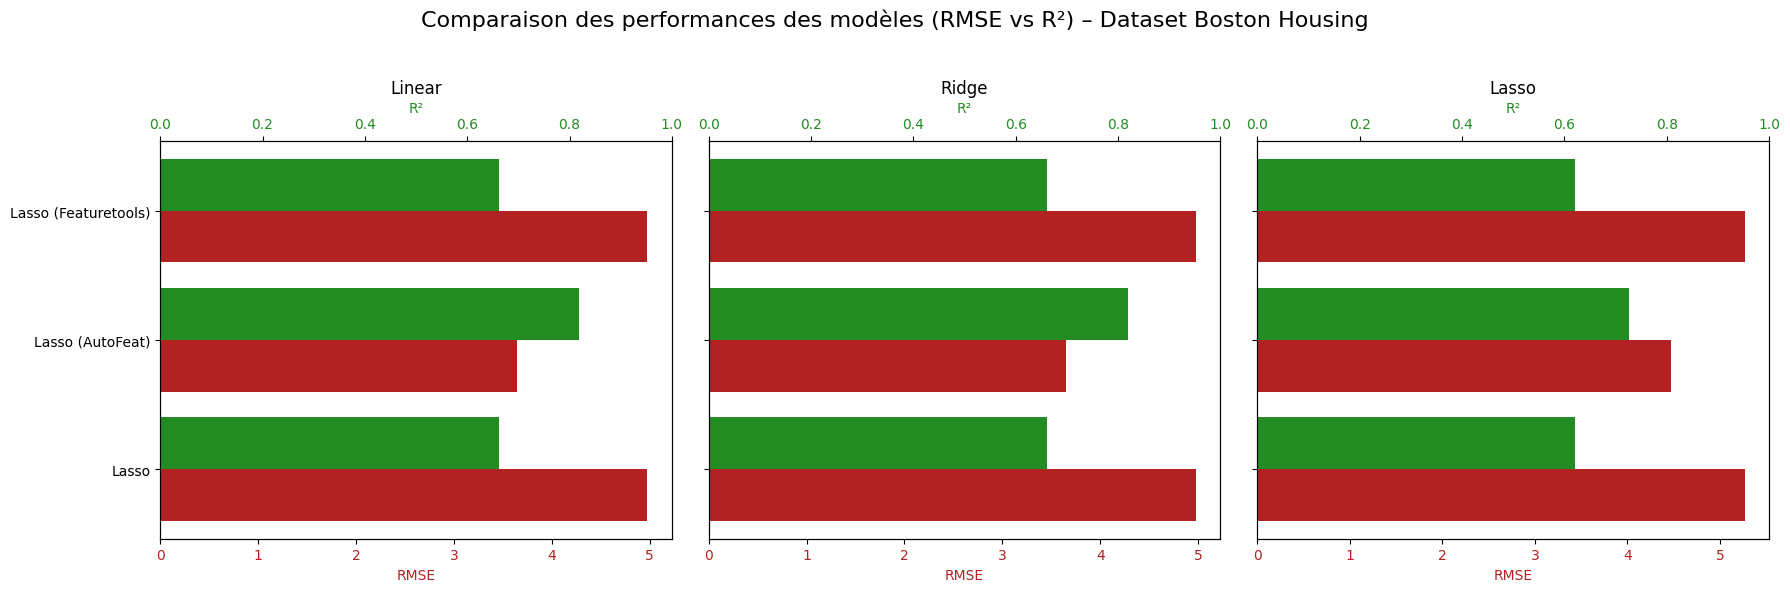

In [14]:
import matplotlib.pyplot as plt
import numpy as np

model_groups = {
    "Linear": {
        "labels": ["Linear", "Linear (AutoFeat)","Linear (Featuretools)"],
        "rmse": [rmse, rmse_af,rmse],
        "r2": [r2, r2_af,r2]
    },
    "Ridge": {
        "labels": ["Ridge", "Ridge (AutoFeat)","Ridge (Featuretools)"],
        "rmse": [rmse_ridge, rmse_ridge_af,rmse_ridge],
        "r2": [r2_ridge, r2_ridge_af,r2_ridge]
    },
    "Lasso": {
        "labels": ["Lasso", "Lasso (AutoFeat)", "Lasso (Featuretools)"],
        "rmse": [rmse_lasso, rmse_lasso_af,rmse_lasso],
        "r2": [r2_lasso, r2_lasso_af,r2_lasso]
    }
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for i, (model_name, data) in enumerate(model_groups.items()):
    ax1 = axes[i]
    y = np.arange(len(data["labels"]))
    bar_height = 0.4

    
    ax1.barh(y - bar_height/2, data["rmse"], height=bar_height, color='firebrick', label='RMSE')
    ax1.set_xlabel("RMSE", color='firebrick')
    ax1.tick_params(axis='x', labelcolor='firebrick')
    ax1.set_yticks(y)
    ax1.set_yticklabels(data["labels"])
    ax1.set_title(model_name)

    
    ax2 = ax1.twiny()
    ax2.barh(y + bar_height/2, data["r2"], height=bar_height, color='forestgreen', label='R²')
    ax2.set_xlim(0, 1)
    ax2.set_xlabel("R²", color='forestgreen')
    ax2.tick_params(axis='x', labelcolor='forestgreen')

fig.suptitle("Comparaison des performances des modèles (RMSE vs R²) – Dataset Boston Housing", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
